In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
import faiss

In [2]:
# The SIFT dataset vectors are stored in .fvecs format. 
# Each vector entry starts with an int32 dimension prefix followed by that many float32 components.

def read_ivecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    return data[:, 1:]

def read_fvecs(fname: str) -> np.ndarray:
    with open(fname, "rb") as f:
        data = np.fromfile(f, dtype=np.int32)

    dim = data[0]
    data = data.reshape(-1, dim + 1)

    # reinterpret everything except first column as float32
    vectors = data[:, 1:].view(np.float32)

    return vectors

BASE = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_base.fvecs"
QUERY = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_query.fvecs"
TRUTH = "/home/adamm/Desktop/filtered-vector-search/siftsmall/siftsmall_groundtruth.ivecs"

base_vectors = read_fvecs(BASE)
query_vectors = read_fvecs(QUERY)
truth_vectors = read_ivecs(TRUTH)

print(f"Dimensions of base: {base_vectors.shape}    Type: {base_vectors.dtype}")
print(f"Dimensions of query: {query_vectors.shape}    Type: {query_vectors.dtype}")
print(f"Dimensions of truth: {truth_vectors.shape}    Type: {truth_vectors.dtype}")

Dimensions of base: (10000, 128)    Type: float32
Dimensions of query: (100, 128)    Type: float32
Dimensions of truth: (100, 100)    Type: int32


In [3]:
n, d = base_vectors.shape
ids = np.arange(n)

In [4]:
def base_clusters(vectors, k, seed=42):
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=1024,
        max_iter=100
    )
    return kmeans.fit_predict(vectors)

def generate_continuous_from_labels(labels, k, corr_strength=1.0, seed=42):
    rng = np.random.default_rng(seed)
    
    # 1. Map labels to a 0-200 signal
    # We spread k clusters across the 0-200 range
    label_means = np.linspace(20, 180, k)
    signal = label_means[labels]
    
    # 2. handle Negative Correlation (-1.0)
    # If negative, we invert the signal: high clusters get low values
    if corr_strength < 0:
        signal = 200 - signal
    
    # 3. Blend with Noise
    # This is equivalent to your 'add_noise' but on a continuous scale
    abs_corr = abs(corr_strength)
    random_noise = rng.uniform(0, 200, size=len(labels))
    
    attr = (abs_corr * signal) + ((1 - abs_corr) * random_noise)
    
    # Add small local jitter so points in same cluster aren't identical
    attr += rng.normal(0, 5, size=len(labels))
    
    return np.clip(attr, 0, 200)

In [7]:
def build_cdf(attr, bins=100):
    hist, edges = np.histogram(attr, bins=bins, density=True)
    cdf = np.cumsum(hist)
    cdf = cdf / cdf[-1]
    return edges, cdf

def get_p_global(edges, cdf, threshold):
    idx = np.searchsorted(edges, threshold)
    if idx >= len(cdf): return 1.0
    return cdf[idx]

def _nearest_clusters(q, centroids, top_L=3):
    distances = np.linalg.norm(centroids - q, axis=1)
    return np.argsort(distances)[:top_L]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

def analyze_sift_correlation(base_vectors, query_vectors, attr, n_clusters=40):
    # 1. Setup K-Means neighborhoods on the BASE vectors
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(base_vectors)
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    cluster_to_indices = {c: np.where(labels == c)[0] for c in range(n_clusters)}
    
    # 2. Global Baseline
    edges, cdf = build_cdf(attr)
    
    results = []
    
    # We iterate through all 100 queries
    for i in range(len(query_vectors)):
        q = query_vectors[i]
        
        # Define a threshold for THIS query (e.g., its own attribute value)
        # This makes the predicate "Aligned"
        threshold_q = 100 # Or use attr[i] if your attr is aligned to query_vectors
        
        p_global = get_p_global(edges, cdf, threshold_q)
        
        # 3. Retrieval (Local Neighborhood)
        neighbor_ids = _nearest_clusters(q, centroids, top_L=2)
        local_idx = np.concatenate([cluster_to_indices[c] for c in neighbor_ids])
        attr_local = attr[local_idx]
        
        # 4. Local Stats
        p_q = np.mean(attr_local < threshold_q)
        direction = p_q - p_global
        
        # JS Divergence (Stability clipped)
        eps = 1e-10
        js_div = jensenshannon(np.clip([p_q, 1-p_q], eps, 1-eps), 
                               np.clip([p_global, 1-p_global], eps, 1-eps))
        
        results.append({
            'js': js_div,
            'dir': direction,
            'p_q': p_q,
            'p_g': p_global
        })
        
    return results

# --- EXECUTION ---
# Generating attributes for different correlation levels
k_struct = 10
kmeans_struct = MiniBatchKMeans(n_clusters=k_struct, random_state=42, n_init="auto").fit(base_vectors)
labels = kmeans_struct.labels_

attr_pos = generate_continuous_from_labels(labels, k_struct, corr_strength=0.9)
attr_neg = generate_continuous_from_labels(labels, k_struct, corr_strength=-0.9)
attr_rand = generate_continuous_from_labels(labels, k_struct, corr_strength=0.0)

res_pos = analyze_sift_correlation(base_vectors, query_vectors, attr_pos)
res_neg = analyze_sift_correlation(base_vectors, query_vectors, attr_neg)
res_rand = analyze_sift_correlation(base_vectors, query_vectors, attr_rand)

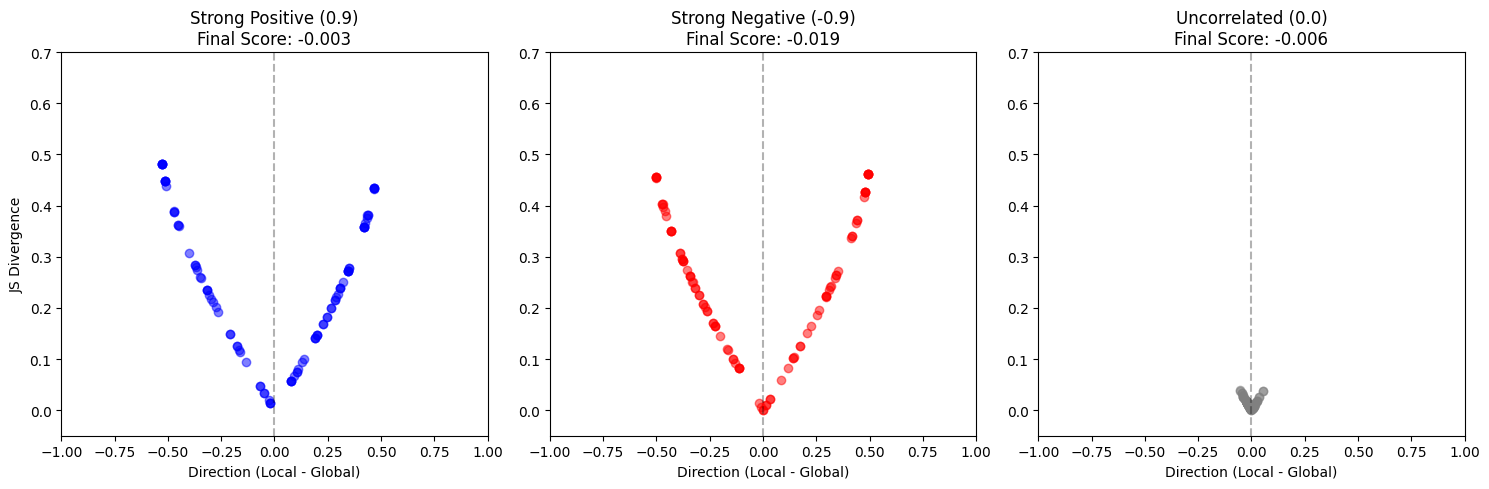

In [9]:
def plot_correlation_summary(res_pos, res_neg, res_rand):
    plt.figure(figsize=(15, 5))
    
    configs = [
        (res_pos, "Strong Positive (0.9)", "blue"),
        (res_neg, "Strong Negative (-0.9)", "red"),
        (res_rand, "Uncorrelated (0.0)", "gray")
    ]
    
    for i, (res, title, color) in enumerate(configs):
        js_vals = [r['js'] for r in res]
        dir_vals = [r['dir'] for r in res]
        
        # Final Correlation Score: Mean(JS * Sign(Direction))
        # This rewards high divergence in the right direction
        scores = [r['js'] * np.sign(r['dir']) for r in res]
        final_score = np.mean(scores)
        
        plt.subplot(1, 3, i+1)
        plt.scatter(dir_vals, js_vals, alpha=0.5, c=color)
        plt.axvline(0, color='black', linestyle='--', alpha=0.3)
        plt.ylim(-0.05, 0.7)
        plt.xlim(-1, 1)
        plt.title(f"{title}\nFinal Score: {final_score:.3f}")
        plt.xlabel("Direction (Local - Global)")
        if i == 0: plt.ylabel("JS Divergence")

    plt.tight_layout()
    plt.show()

plot_correlation_summary(res_pos, res_neg, res_rand)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from scipy.spatial.distance import jensenshannon

def analyze_sift_correlation(base_vectors, query_vectors, attr_base, attr_query, n_clusters=40):
    # 1. Setup K-Means neighborhoods on the BASE vectors
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit(base_vectors)
    centroids = kmeans.cluster_centers_
    cluster_labels = kmeans.labels_
    cluster_to_indices = {c: np.where(cluster_labels == c)[0] for c in range(n_clusters)}
    
    # 2. Global Baseline (CDF of the base attributes)
    edges, cdf = build_cdf(attr_base)
    
    results = []
    
    # Iterate through all queries
    for i in range(len(query_vectors)):
        q = query_vectors[i]
        
        # PREDICATE: Use the query's own attribute as the threshold
        threshold_q = attr_query[i]
        
        # Global probability: P(attr < query_attr)
        p_global = get_p_global(edges, cdf, threshold_q)
        
        # 3. Retrieval (Local Neighborhood)
        neighbor_ids = _nearest_clusters(q, centroids, top_L=2)
        local_idx = np.concatenate([cluster_to_indices[c] for c in neighbor_ids])
        attr_local = attr_base[local_idx]
        
        # 4. Local Stats
        p_q = np.mean(attr_local < threshold_q)
        direction = p_q - p_global
        
        # JS Divergence
        eps = 1e-10
        js_div = jensenshannon(np.clip([p_q, 1-p_q], eps, 1-eps), 
                               np.clip([p_global, 1-p_global], eps, 1-eps))
        
        results.append({
            'js': js_div,
            'dir': direction,
            'p_q': p_q,
            'p_g': p_global
        })
        
    # We return the results PLUS the clustering data for plotting
    return results, centroids, cluster_to_indices

# --- EXECUTION ---

# 1. Structural Clustering (Base)
k_struct = 10
kmeans_struct = MiniBatchKMeans(n_clusters=k_struct, random_state=42, n_init="auto").fit(base_vectors)
labels_base = kmeans_struct.labels_
labels_query = kmeans_struct.predict(query_vectors)

# 2. Generate Aligned Attributes
attr_pos_base = generate_continuous_from_labels(labels_base, k_struct, corr_strength=0.9)
attr_pos_query = generate_continuous_from_labels(labels_query, k_struct, corr_strength=0.9)

attr_neg_base = generate_continuous_from_labels(labels_base, k_struct, corr_strength=-0.9)
attr_neg_query = generate_continuous_from_labels(labels_query, k_struct, corr_strength=-0.9)

attr_rand_base = generate_continuous_from_labels(labels_base, k_struct, corr_strength=0.0)
attr_rand_query = generate_continuous_from_labels(labels_query, k_struct, corr_strength=0.0)

# 3. Run Analysis (Unpacking results and metadata)
res_pos, centroids_pos, idx_map_pos = analyze_sift_correlation(base_vectors, query_vectors, attr_pos_base, attr_pos_query)
res_neg, centroids_neg, idx_map_neg = analyze_sift_correlation(base_vectors, query_vectors, attr_neg_base, attr_neg_query)
res_rand, centroids_rand, idx_map_rand = analyze_sift_correlation(base_vectors, query_vectors, attr_rand_base, attr_rand_query)

In [ ]:
def print_summary(res, name):
    avg_js = np.mean([r['js'] for r in res])
    avg_dir = np.mean([r['dir'] for r in res])
    # The final correlation score: how much divergence matches the intended direction
    score = np.mean([r['js'] * np.sign(r['dir']) for r in res])
    print(f"{name:10} | Avg JS: {avg_js:.3f} | Avg Dir: {avg_dir:+.3f} | Score: {score:+.3f}")

print_summary(res_pos, "Positive")
print_summary(res_neg, "Negative")
print_summary(res_rand, "Random")